# Paper Mill Cost Optimization - Training Pipeline

This notebook trains predictive models for paper machine KPIs using:
1. CMA-ES feature selection with Ridge regression
2. Residual state estimation (Local Level via UCM)
3. Iterative backfitting (regression + state decomposition)

All reusable logic lives in companion modules:
- `config.py` - Target/feature mappings, variable group definitions
- `data_cleaning.py` - Outlier detection, design matrix construction, helpers
- `feature_selection.py` - CMA-ES evolutionary feature selection
- `preprocessing.py` - PLS dimensionality reduction pipeline
- `state_estimation.py` - UCM state estimation + iterative backfitting

## 1. Imports

In [1]:
import sys
from pathlib import Path

# Add parent directory (where utility.py lives) to the path
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from sklearn.model_selection import TimeSeriesSplit

from utility import GroupwisePLSTransformer, _feature_engineering, setpoint_df

from config import CONTROL_VARS
from data_cleaning import (
    unique_in_order, ordered_difference, ordered_intersection,
    outlier, make_design,
)
from preprocessing import make_prep_pip

sns.set(rc={"figure.figsize": (12, 4)})
sns.set_style("whitegrid")
sns.set_context("notebook")

## 2. Configuration

In [2]:
Y_COLUMN = "Steam__kWh/T_"
DATA_PATH = "../data/costimier_turnup.parquet"

TIME_AWARE = True
USE_HOLDOUT = True
APPLY_EWM_FILTER = False

TEST_SIZE = 0.20
RANDOM_STATE = 42
N_SPLITS = 5
LAGS = 0

PIPELINE_PREFIXES = ["exha_mois", "inlet_temp", "linepressure", "fabric_tension", "gas_decu"]

BLACK_LIST = [
    "Current_basis_weight", "Bentonite_1_mass_flow__g/T_",
    "Bentonite_2_mass_flow__g/T_", "DG3_Moisture_content_Outlet_Air",
    "Lip_settings", "Conductivity_white_water_B46",
    "pH-Messung_Verd\u00fcnnungswasser__2..12_pH_",
    "pH_measurement_white_water_B41", "CO2_mass_flow__g/T_",
]

CREATED_VARIABLE_CANDIDATES = [
    "Water_Predryer", "diluted_starch", "Fibre__g/m2_",
    "Water_Afterdryer_output", "dewatering",
    "inv_Production_Rate__T/h_", "fibre_short/long",
]

## 3. Data Loading & Filtering

In [3]:
# Build PLS preprocessing pipeline
prep_pip, prep_s_vars = make_prep_pip(prefixes=PIPELINE_PREFIXES)

# Load raw data
turnup_data = pd.read_parquet(DATA_PATH)

# Get control variables for the target (excluding vacuum)
ctl_vars = unique_in_order(
    v for v in CONTROL_VARS[Y_COLUMN] if "vacuum" not in v.lower()
)

# Derived variables are created inside build_pre_estimator via FeatureCreator
created_vars = ordered_intersection(CREATED_VARIABLE_CANDIDATES, ctl_vars)

# Feature engineering
turnup_data = _feature_engineering(turnup_data, setpoint_df, steam_null=False, clip=False)
turnup_data = turnup_data.set_index("Wedge_Time").sort_index()

# Time-based filtering
turnup_data = turnup_data[turnup_data.index > "2025-04-01"]
turnup_data = turnup_data[~((turnup_data.index > "2026-01-24 07:00") & (turnup_data.index < "2026-01-26 10:00"))]
turnup_data = turnup_data[~((turnup_data.index > "2026-01-11 12:00") & (turnup_data.index < "2026-01-12 11:00"))]
turnup_data = turnup_data[~((turnup_data.index > "2026-01-17 12:00") & (turnup_data.index < "2026-01-19 11:00"))]

# Physical-constraint filtering
turnup_data = turnup_data[
    (turnup_data["Condensate_energy_from_paper_plant_to_power_plant"].between(5, 10))
    & (turnup_data["DG4_Temperature_Inlet_Air"] > 100)
    & (turnup_data["Vacuum_Zone_1_PickUp"] < -0.5)
]

print(f"Filtered data shape: {turnup_data.shape}")

Filtered data shape: (6810, 522)


## 4. Build Preprocessing Pipeline

In [4]:
import re
from preprocessing import build_pre_estimator

# Determine fixed features (always included in CMA-ES)
fixed_features = [
    "ambient_temp_C", "exha_mois_1", "exha_mois_2",
    "inlet_temp_1", "inlet_temp_2", "linepressure_1",
    "fabric_tension_1", "gas_decu_1", "gas_decu_2", "gas_decu_3",
    "grammage",
]

# Build reduced candidate variable list (desired output features)
steam_pressure = [v for v in turnup_data.columns if re.search(r"cylinder.*steam_pressure", v, re.I)]
steam_diff_pressure = [v for v in turnup_data.columns if re.search(r"cylinder.*differential_pressure", v, re.I)]

exog_vars_reduced = [
    v for v in ctl_vars
    if (v not in BLACK_LIST and v not in created_vars
        and v not in steam_pressure and v not in steam_diff_pressure
        and "vacuum" not in v.lower())
]
exog_vars_reduced = unique_in_order(fixed_features + exog_vars_reduced + ["grammage"])

# Replace PLS source columns with their transformed scores
for _, step in prep_pip.steps:
    if isinstance(step, GroupwisePLSTransformer):
        transformed_names = [f"{step.score_prefix}_{i}" for i in range(1, step.n_components + 1)]
        exog_vars_reduced = ordered_difference(
            unique_in_order(exog_vars_reduced + transformed_names),
            list(step.pls_columns),
        )

exog_vars_reduced = unique_in_order(fixed_features + exog_vars_reduced)

# Build pipeline: FeatureCreator -> (EWM) -> PLS -> Filter -> Scaler/Encoder
pre_estimator, feat_list = build_pre_estimator(
    exog_vars_reduced=exog_vars_reduced,
    prep_pip=prep_pip,
    created_vars=created_vars,
    apply_ewm=APPLY_EWM_FILTER,
)

print(f"Pipeline input columns ({len(feat_list)}): {feat_list}")
print(f"Pipeline output features: {exog_vars_reduced}")

Pipeline input columns (62): ['ambient_temp_C', 'Draw_PS-PD1', 'Moisture_out_of_PreDryer', 'Draw_WS-PS', 'PickUp_Tension', 'Dewatering_top_wire_suction_box_zone_2', 'White_water_temperature', 'Top_wire_tenstion', 'Jet/wire_ratio', 'Top_Felt_Tension', 'Bottom_wire_tension', 'Bottom_Felt_Tension', 'Air_pressure_of_rod_clamping_hose_Top_Roll', 'Airturn_pillow_pressure', 'Dewatering_Suction_Press_Roll', 'Dewatering_First_Press_Roll', 'Steam_temperature_for_PM', 'Steam_pressure_for_PM', 'Dewatering_Shoe_press', 'Total_Dewatering_Press', 'Uhle_box_1_flow___l/min_', 'Stock_deculator_temperature', 'Stock_deculator_pressure', 'Inlet_Air_2_Temperature', 'Inlet_Air_1_Temperature', 'DG1_Ventilator_Revolution_Output', 'DG2_Ventilator_Revolution_Output', 'DG3_Ventilator_Revolution_Output', 'retention', 'Web_tension_AD6', 'AD7_fabric_tension_bottom', 'Act_Deaerator_mass_flow__g/T_', 'Retention_Aid_mass_flow__g/T_', 'Natriumhydroxide_mass_flow__g/T_', 'Fixative_2_mass_flow__g/T_', 'grammage', 'DG1_Moi

## 5. Transform & Build Design Matrix

In [5]:
# Prepare time series subset
turnup_ts = turnup_data.copy().sort_index()
turnup_ts = turnup_ts.loc[turnup_ts.index > pd.Timestamp("2025-11-15")]
turnup_ts = turnup_ts.loc[~outlier(turnup_ts[Y_COLUMN], option="PctClip")].copy()

# Chronological split point (fit pipeline on train portion only)
n_samples = len(turnup_ts)
split = int(n_samples * (1.0 - TEST_SIZE))

# Fit pipeline on training rows, transform entire series
ts_raw = turnup_ts.loc[:, feat_list]
pre_estimator.fit(ts_raw.iloc[:split], turnup_ts[Y_COLUMN].iloc[:split])
ts_transformed = pre_estimator.transform(ts_raw)

# Attach target for make_design
ts_transformed[Y_COLUMN] = turnup_ts[Y_COLUMN].values

# Build design matrix (lags applied on transformed features)
transformed_feature_names = [c for c in ts_transformed.columns if c != Y_COLUMN]
X, y = make_design(ts_transformed, Y_COLUMN, transformed_feature_names, None, y_lags=range(1, 1 + LAGS))

print(f"Design matrix: X={X.shape}, y={y.shape}")
print(f"Transformed features ({len(transformed_feature_names)}): {transformed_feature_names}")

Design matrix: X=(3320, 49), y=(3320,)
Transformed features (49): ['ambient_temp_C', 'Draw_PS-PD1', 'Moisture_out_of_PreDryer', 'Draw_WS-PS', 'PickUp_Tension', 'Dewatering_top_wire_suction_box_zone_2', 'White_water_temperature', 'Top_wire_tenstion', 'Jet/wire_ratio', 'Top_Felt_Tension', 'Bottom_wire_tension', 'Bottom_Felt_Tension', 'Air_pressure_of_rod_clamping_hose_Top_Roll', 'Airturn_pillow_pressure', 'Dewatering_Suction_Press_Roll', 'Dewatering_First_Press_Roll', 'Steam_temperature_for_PM', 'Steam_pressure_for_PM', 'Dewatering_Shoe_press', 'Total_Dewatering_Press', 'Uhle_box_1_flow___l/min_', 'Stock_deculator_temperature', 'Stock_deculator_pressure', 'Inlet_Air_2_Temperature', 'Inlet_Air_1_Temperature', 'DG1_Ventilator_Revolution_Output', 'DG2_Ventilator_Revolution_Output', 'DG3_Ventilator_Revolution_Output', 'retention', 'Web_tension_AD6', 'AD7_fabric_tension_bottom', 'Act_Deaerator_mass_flow__g/T_', 'Retention_Aid_mass_flow__g/T_', 'Natriumhydroxide_mass_flow__g/T_', 'Fixative_2_m

## 6. Train/Test Split

In [6]:
# Re-compute split on design matrix (may lose rows due to lags/NaN)
n_samples = len(X)
split = int(n_samples * (1.0 - TEST_SIZE))

Xtr, Xte = X.iloc[:split].copy(), X.iloc[split:].copy()
ytr, yte = y.iloc[:split].copy(), y.iloc[split:].copy()

outer_cv = [(np.arange(split), np.arange(split, n_samples))]

print(f"Train: {Xtr.shape}, Test: {Xte.shape}")

Train: (2656, 49), Test: (664, 49)


## 7. CMA-ES Feature Selection

In [10]:
from feature_selection import cmaes_feature_selection, collinearity_penalty, parsimony_penalty

# Resolve fixed feature names (expand grammage one-hot)
fixed_features_resolved = (
    [v for v in fixed_features if "grammage" not in v.lower()]
    + [v for v in X.columns if "grammage" in v.lower()]
)

# Derive group constraints from PLS pipeline (all-or-nothing selection)
feature_groups = {
    step.score_prefix: [f"{step.score_prefix}_{i}" for i in range(1, step.n_components + 1)]
    for _, step in prep_pip.steps
    if isinstance(step, GroupwisePLSTransformer)
}

# Run CMA-ES with k auto-tuning and group constraints
res = cmaes_feature_selection(
    X, np.array(y).ravel(),
    k_range=(3, 15),
    fixed_features=fixed_features_resolved,
    feature_groups=feature_groups,
    cv_splits=outer_cv,
    selection="topk",
    max_evals=5000,
    sigma0=1.0,
    seed=42,
    popsize=24,
    penalty_fn=None,
    verbose=True,
)

selected_features = res.selected_features
print(f"\nSelected {res.n_atoms} atoms -> {res.n_features} features")
print(f"Atoms: {res.selected_atoms}")
print(f"Features: {selected_features}")
print(f"Best RMSE: {res.best_rmse:.3f}, alpha: {res.best_alpha:.2f}")

Search space: 34 atoms (0 groups, 34 standalone)


CMA-ES (34 atoms, k=tune):   0%|          | 0/5000 [00:00<?, ?it/s]

  NEW BEST: loss=36.2656 rmse=36.2656 atoms=11 features=26 evals=1
  NEW BEST: loss=35.7640 rmse=35.7640 atoms=7 features=22 evals=2
  NEW BEST: loss=34.1236 rmse=34.1236 atoms=9 features=24 evals=3
  NEW BEST: loss=33.2458 rmse=33.2458 atoms=6 features=21 evals=4
  NEW BEST: loss=31.3964 rmse=31.3964 atoms=9 features=24 evals=12
  NEW BEST: loss=30.9362 rmse=30.9362 atoms=8 features=23 evals=20
  NEW BEST: loss=30.1856 rmse=30.1856 atoms=8 features=23 evals=70
  NEW BEST: loss=30.1763 rmse=30.1763 atoms=8 features=23 evals=77
  NEW BEST: loss=29.8094 rmse=29.8094 atoms=12 features=27 evals=144
  NEW BEST: loss=29.5280 rmse=29.5280 atoms=11 features=26 evals=152
  NEW BEST: loss=29.1073 rmse=29.1073 atoms=14 features=29 evals=175
  NEW BEST: loss=29.1066 rmse=29.1066 atoms=14 features=29 evals=578
  NEW BEST: loss=29.1043 rmse=29.1043 atoms=15 features=30 evals=703

Selected 15 atoms -> 30 features
Atoms: ['Draw_PS-PD1', 'Moisture_out_of_PreDryer', 'Draw_WS-PS', 'Top_Felt_Tension', 'Bo

## 8. Final Pipeline

In [11]:
from preprocessing import build_final_pipeline

# Get best alpha from CMA-ES result
best_alpha = res.best_alpha

# Build end-to-end pipeline: raw data -> features -> Ridge
final_pipeline, feat_list_final = build_final_pipeline(
    selected_features=selected_features,
    prep_pip=prep_pip,
    created_vars=created_vars,
    ridge_alpha=best_alpha,
    apply_ewm=APPLY_EWM_FILTER,
)

# Fit on training portion of the raw time series
ts_raw_final = turnup_ts.loc[:, feat_list_final]
final_pipeline.fit(ts_raw_final.iloc[:split], turnup_ts[Y_COLUMN].iloc[:split])

# Predict on test portion
y_pred = final_pipeline.predict(ts_raw_final.iloc[split:])
y_actual = turnup_ts[Y_COLUMN].iloc[split:]

print(f"Final pipeline steps: {[name for name, _ in final_pipeline.steps]}")
print(f"Input columns: {len(feat_list_final)}")

Final pipeline steps: ['feat', 'exha_mois', 'inlet_temp', 'linepressure', 'fabric_tension', 'gas_decu', 'filter', 'scaler_encoder', 'ridge']
Input columns: 43


## 9. Model Evaluation

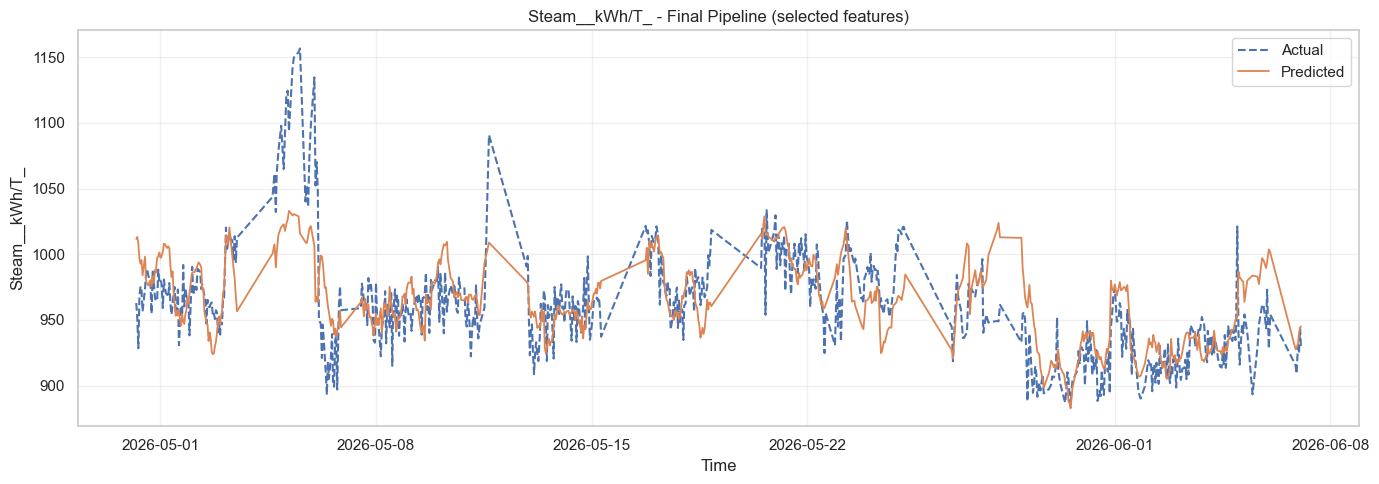

Test RMSE: 29.10, MAE: 21.18, R2: 0.4730


In [12]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Plot actual vs predicted
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(y_actual.index, y_actual.values, label='Actual', lw=1.5, ls='--')
ax.plot(y_actual.index, y_pred, label='Predicted', lw=1.3)
ax.set_title(f'{Y_COLUMN} - Final Pipeline (selected features)')
ax.set_xlabel('Time')
ax.set_ylabel(Y_COLUMN)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

rmse = np.sqrt(mean_squared_error(y_actual, y_pred))
r2 = r2_score(y_actual, y_pred)
mae = mean_absolute_error(y_actual, y_pred)
print(f'Test RMSE: {rmse:.2f}, MAE: {mae:.2f}, R2: {r2:.4f}')

## Mathematical Formulation: Iterative Regression + State Decomposition

The approach below implements a **backfitting** algorithm (Hastie & Tibshirani, 1990), closely related to 
**ECM (Expectation-Conditional Maximization)** for additive models. It decomposes the target into a 
regression component and a latent local-level state.

### Model

$$
y_t = s_t + X_t^\top \beta + \epsilon_t
$$

with a local-level (random walk) state:

$$
s_t = s_{t-1} + \eta_t, \quad \eta_t \sim \mathcal{N}(0, \sigma_\eta^2)
$$

and observation noise $\epsilon_t \sim \mathcal{N}(0, \sigma_\epsilon^2)$.

- $X_t^\top \beta$: contribution explained by process variables (Ridge regression)
- $s_t$: persistent latent drift (unobserved disturbances, slow process changes)
- $\epsilon_t$: observation noise

### Alternating Estimation Scheme

**Iteration 0:** Initialize $\hat{s}_t^{(0)} = 0$.

**General iteration $k$:**

1. **Regression step** â€” fit on the de-stated target:
$$
\hat{\beta}^{(k)} = \arg\min_\beta \sum_t \left( (y_t - \hat{s}_t^{(k)}) - X_t^\top \beta \right)^2 + \lambda \|\beta\|^2
$$

2. **Residual computation** â€” from the *original* target:
$$
r_t^{(k)} = y_t - X_t^\top \hat{\beta}^{(k)}
$$

   Note: $r_t^{(k)} \approx s_t + \epsilon_t$ (contains both state and noise).

3. **State estimation** â€” Kalman smoother separates state from noise:
$$
\hat{s}_t^{(k+1)} = \mathbb{E}\left[ s_t \mid r_{1:T}^{(k)} \right]
$$

The cycle repeats:

$$
\boxed{\hat{s}^{(k)} \rightarrow \hat{\beta}^{(k)} \rightarrow r^{(k)} \rightarrow \hat{s}^{(k+1)}}
$$

### Why not set $\hat{s}_t = r_t$ directly?

Because $r_t = s_t + \epsilon_t$. Assigning the full residual to the state would absorb the noise, 
leading to overfitting. The Kalman smoother optimally separates the persistent component ($s_t$) from 
the transient noise ($\epsilon_t$) by estimating $\sigma_\eta^2 / \sigma_\epsilon^2$ via MLE.

### Connection to standard methods

- **Backfitting** (Hastie & Tibshirani, 1990): alternates between estimating each additive component 
  while holding others fixed. Here the two components are $X\beta$ and $s_t$.
- **ECM** (Meng & Rubin, 1993): a generalization of EM where each M-step is split into conditional 
  maximizations. Here: (1) maximize over $\beta$ given $\hat{s}$, (2) maximize over $s$ given $\hat{\beta}$.
- **Structural Time Series** (Harvey, 1989): the full joint model. Our iterative approach approximates 
  the joint MLE by alternating, which is computationally cheaper and allows using feature selection 
  (CMA-ES) in the regression step.

### Convergence

Each iteration reduces the penalized negative log-likelihood. In practice, 2-3 iterations suffice 
because the level and regression are near-orthogonal (the regression captures fast/correlated variation, 
the level captures slow drift).

## 10. Iterative Backfitting (Regression + State)

In [ ]:
from state_estimation import iterative_backfit
from feature_selection import cmaes_feature_selection, fit_all_features

SKIP_FEATURE_SELECTION = True

def run_feature_selection(X_full, y_full, iteration, splines=False):
    if SKIP_FEATURE_SELECTION:
        return fit_all_features(X_full, y_full, cv_splits=outer_cv, splines=splines)
    else:
        return cmaes_feature_selection(
            X_full, y_full,
            k_range=(3, 15),
            fixed_features=fixed_features_resolved,
            feature_groups=feature_groups,
            cv_splits=outer_cv,
            selection='topk',
            max_evals=3000,
            sigma0=1.0,
            seed=42,
            popsize=24,
            penalty_fn=None,
            splines=splines,
            verbose=False,
        )

# Run iterative backfitting
backfit_result = iterative_backfit(
    X=X,
    y=y,
    train_idx=np.arange(split),
    test_idx=np.arange(split, len(X)),
    feature_selection_fn=run_feature_selection,
    n_iterations=100,
    patience=2,
    state_estimator_kwargs={'level': True, 'stochastic_level': True},
    splines=False,
    verbose=True,
)


ITERATION 1/100

  Step A: Feature selection on adjusted target...
  Step C: Fitting state estimator on residuals...

  Results (iteration 1):
    Features: 49
    Ridge RMSE: 30.362, R2: 0.4265
    Combined RMSE: 13.205, R2: 0.8915
    Level scale: 10.0763
    *** New best ***

ITERATION 2/100

  Step A: Feature selection on adjusted target...
  Step C: Fitting state estimator on residuals...

  Results (iteration 2):
    Features: 49
    Ridge RMSE: 27.775, R2: 0.5200
    Combined RMSE: 12.964, R2: 0.8954
    Level scale: 9.8661
    *** New best ***

ITERATION 3/100

  Step A: Feature selection on adjusted target...
  Step C: Fitting state estimator on residuals...

  Results (iteration 3):
    Features: 49
    Ridge RMSE: 26.939, R2: 0.5485
    Combined RMSE: 12.914, R2: 0.8962
    Level scale: 9.7971
    *** New best ***

ITERATION 4/100

  Step A: Feature selection on adjusted target...
  Step C: Fitting state estimator on residuals...

  Results (iteration 4):
    Features: 49
 

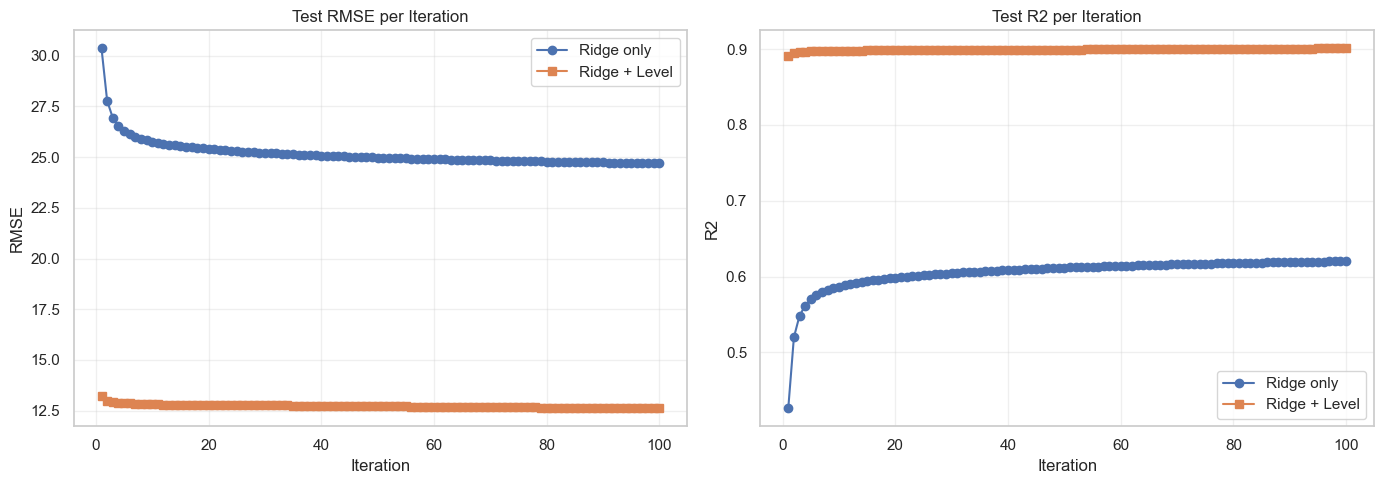

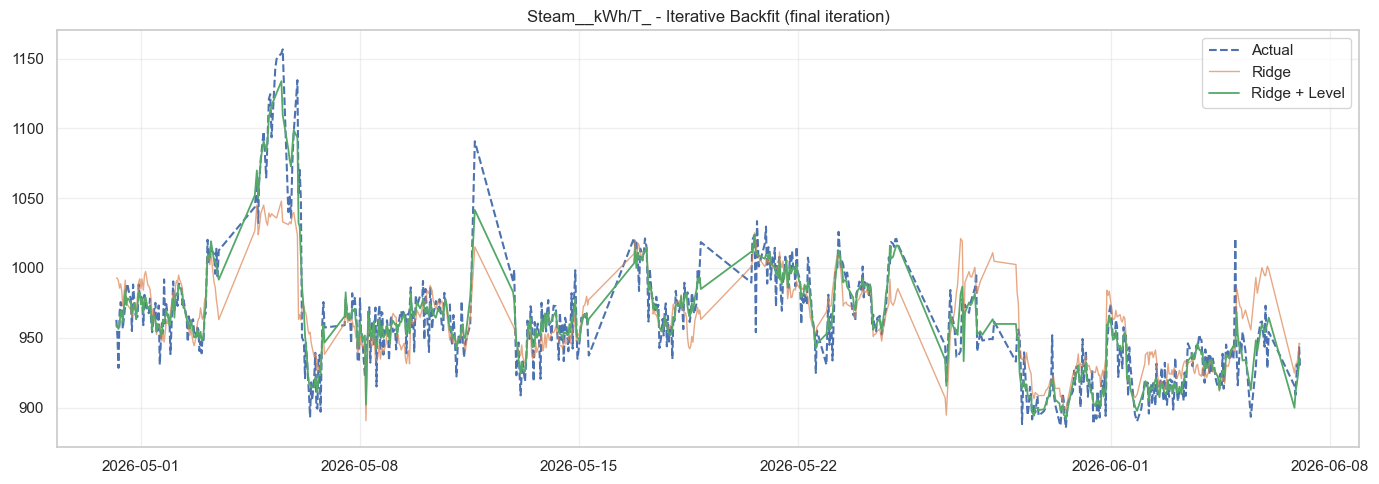

In [11]:
# Plot convergence across iterations
history = backfit_result['iteration_history']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

iters = [h['iteration'] for h in history]
axes[0].plot(iters, [h['rmse_ridge'] for h in history], 'o-', label='Ridge only')
axes[0].plot(iters, [h['rmse_combined'] for h in history], 's-', label='Ridge + Level')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('RMSE')
axes[0].set_title('Test RMSE per Iteration')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(iters, [h['r2_ridge'] for h in history], 'o-', label='Ridge only')
axes[1].plot(iters, [h['r2_combined'] for h in history], 's-', label='Ridge + Level')
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('R2')
axes[1].set_title('Test R2 per Iteration')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Final prediction plot
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(yte.index, yte.values, label='Actual', lw=1.5, ls='--')
ax.plot(backfit_result['y_test_pred'].index, backfit_result['y_test_pred'].values,
        label='Ridge', lw=1.0, alpha=0.7)
ax.plot(backfit_result['y_test_combined'].index, backfit_result['y_test_combined'].values,
        label='Ridge + Level', lw=1.3)
ax.set_title(f'{Y_COLUMN} - Iterative Backfit (final iteration)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 11. Final Pipeline: Fit & Evaluate on Raw Data

In [12]:
from preprocessing import build_final_pipeline
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Build minimal pipeline for the selected features + Ridge
final_pipeline, feat_list_final = build_final_pipeline(
    selected_features=backfit_result['selected_features'],
    prep_pip=prep_pip,
    created_vars=created_vars,
    ridge_alpha=backfit_result['feature_selection_result'].best_alpha,
    apply_ewm=APPLY_EWM_FILTER,
)

# Fit on raw train data with adjusted target (y - level)
y_adjusted_train = turnup_ts[Y_COLUMN].iloc[:split] - backfit_result['level_train'].values
final_pipeline.fit(turnup_ts[feat_list_final].iloc[:split], y_adjusted_train)

# Predict on raw test data
y_test_pred = final_pipeline.predict(turnup_ts[feat_list_final].iloc[split:])
y_test_actual = turnup_ts[Y_COLUMN].iloc[split:].values

# Metrics
rmse = np.sqrt(mean_squared_error(y_test_actual, y_test_pred))
mae = mean_absolute_error(y_test_actual, y_test_pred)
r2 = r2_score(y_test_actual, y_test_pred)
print(f'Final pipeline (without level correction):')
print(f'  RMSE: {rmse:.2f}, MAE: {mae:.2f}, R2: {r2:.4f}')
print(f'  Steps: {[name for name, _ in final_pipeline.steps]}')
print(f'  Input columns: {feat_list_final}')

Final pipeline (without level correction):
  RMSE: 26.27, MAE: 19.13, R2: 0.5706
  Steps: ['feat', 'exha_mois', 'inlet_temp', 'linepressure', 'fabric_tension', 'gas_decu', 'filter', 'scaler_encoder', 'ridge']
  Input columns: ['ambient_temp_C', 'Draw_PS-PD1', 'Moisture_out_of_PreDryer', 'Draw_WS-PS', 'PickUp_Tension', 'Dewatering_top_wire_suction_box_zone_2', 'White_water_temperature', 'Top_wire_tenstion', 'Jet/wire_ratio', 'Top_Felt_Tension', 'Bottom_wire_tension', 'Bottom_Felt_Tension', 'Air_pressure_of_rod_clamping_hose_Top_Roll', 'Airturn_pillow_pressure', 'Dewatering_Suction_Press_Roll', 'Dewatering_First_Press_Roll', 'Steam_temperature_for_PM', 'Steam_pressure_for_PM', 'Dewatering_Shoe_press', 'Total_Dewatering_Press', 'Uhle_box_1_flow___l/min_', 'Stock_deculator_temperature', 'Stock_deculator_pressure', 'Inlet_Air_2_Temperature', 'Inlet_Air_1_Temperature', 'DG1_Ventilator_Revolution_Output', 'DG2_Ventilator_Revolution_Output', 'DG3_Ventilator_Revolution_Output', 'retention', 'We

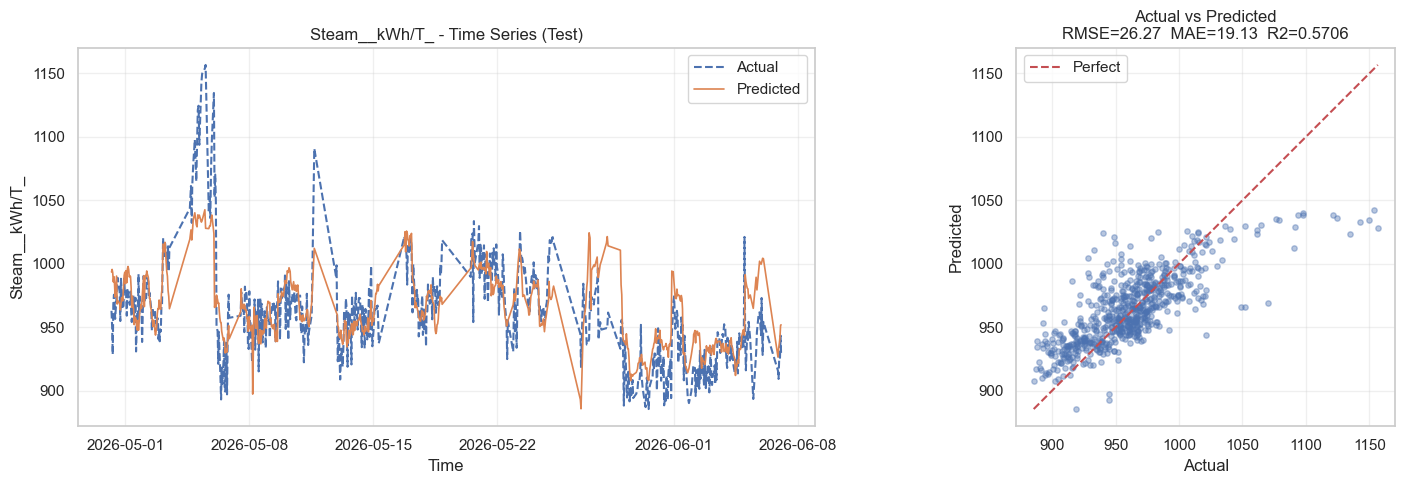

In [13]:
# Time series plot and scatter plot
test_index = turnup_ts.index[split:]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Time series
axes[0].plot(test_index, y_test_actual, label='Actual', lw=1.5, ls='--')
axes[0].plot(test_index, y_test_pred, label='Predicted', lw=1.2)
axes[0].set_title(f'{Y_COLUMN} - Time Series (Test)')
axes[0].set_xlabel('Time')
axes[0].set_ylabel(Y_COLUMN)
axes[0].legend()
axes[0].grid(alpha=0.3)

# Scatter plot
axes[1].scatter(y_test_actual, y_test_pred, alpha=0.4, s=15)
lims = [min(y_test_actual.min(), y_test_pred.min()),
        max(y_test_actual.max(), y_test_pred.max())]
axes[1].plot(lims, lims, 'r--', lw=1.5, label='Perfect')
axes[1].set_xlabel('Actual')
axes[1].set_ylabel('Predicted')
axes[1].set_title(f'Actual vs Predicted\nRMSE={rmse:.2f}  MAE={mae:.2f}  R2={r2:.4f}')
axes[1].legend()
axes[1].grid(alpha=0.3)
axes[1].set_aspect('equal', adjustable='box')

plt.tight_layout()
plt.show()